# PowerModelsONM Export

Emit a single OpenDSS entrypoint and PowerModelsONM companion files from the canonical Stage B artifacts, then preview the four MVP event-window slices that turn the Augmented Network into per-event ONM inputs.

This notebook:
1. Normalizes the DiTTo-written OpenDSS files to the Stage B artifact namespace.
2. Materializes critical-facility `LoadShape` objects from `load_profile_assignments.parquet`.
3. Exports transparent DER generator proxies from `der_inventory.parquet` (REopt-sized rows
 only; zero-size results are recorded as comments, not live generators).
4. Writes the ONM settings sidecar with block membership and switch states.
5. Slices a 72-hour event window anchored at the SFINCS event start.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

from study_location import bootstrap
session = bootstrap()
location_root = session.location_root
repo_root = session.repo_root

# load Location Workspace config and standard grid paths.
from location_runtime import build_grid_paths
from location_runtime import load_runtime as load_config_runtime

config, paths = load_config_runtime(location_root / "config.yaml")
grid = build_grid_paths(config)
location_root = paths["location_root"]
location_name = paths["location_name"]
repo_root = paths["repo_root"]
for key in (
    "shift_cache",
    "opendss_root",
    "asset_registry",
    "augmented_artifacts",
    "onm_export",
    "figures",
):
    grid[key].mkdir(parents=True, exist_ok=True)


onm_export: /home/grahamhults/projects/Flood-RM/locations/marshfield/data/power_grid/onm_export


### Load Stage B (curated) Artifacts

In [2]:
blocks = pd.read_parquet(grid["augmented_artifacts"] / "switch_bounded_load_blocks.parquet")
switches = pd.read_parquet(grid["augmented_artifacts"] / "controllable_switches.parquet")
der_inventory = pd.read_parquet(grid["augmented_artifacts"] / "der_inventory.parquet")
load_profiles = pd.read_parquet(grid["augmented_artifacts"] / "load_profile_assignments.parquet")

print(f"{len(blocks)} blocks, {len(switches)} switches, {len(der_inventory)} DER rows")

192 blocks, 150 switches, 15 DER rows


### PowerModelsONM Export

Normalize OpenDSS bus namespaces to Stage B artifact IDs and write the ONM settings
sidecar. 

In [3]:
# create control-sandbox, restoration, and PowerModelsONM artifacts.
from power.exports import export_powermodels_onm

onm_manifest = export_powermodels_onm(
    opendss_root=grid["opendss_root"],
    asset_registry_dir=grid["asset_registry"],
    blocks=blocks,
    switches=switches,
    der_inventory=der_inventory,
    load_profiles=load_profiles,
    output_dir=grid["onm_export"],
)
display(pd.Series(onm_manifest, name="onm_export_manifest"))

der_export {'not_reopt_sized_provisional_rows': 15, 'prov...
feeder_count 44
gdm_bridge {'available': True, 'package': 'gdm', 'role':...
network_dss /home/grahamhults/projects/Flood-RM/locations/...
schema_version marshfield_powermodels_onm_export.v0.1
settings /home/grahamhults/projects/Flood-RM/locations/...
source_count 42
stage_b_onm_metadata /home/grahamhults/projects/Flood-RM/locations/...
Name: onm_export_manifest, dtype: object

Preview the four MVP slices for a sample event window:
1. Nodal demand assignment (Eversource MA MDPU 1310 rate-class kW thresholds)
2. 72-hour profile slice anchored at the SFINCS event start
3. Per-(load, timestep) ±20% uncertainty bands by block
4. Block-level load uncertainty summary

In [4]:
# create control-sandbox, restoration, and PowerModelsONM artifacts.
from power.exports import build_event_window_bundle
import datetime

# Use a sample event start for preview; real event starts come from the Event Catalog.
sample_event_start = datetime.datetime(2018, 3, 2, 12, 0)  # Riley nor'easter

bundle = build_event_window_bundle(
    event_start=sample_event_start,
    horizon_hours=72,
    load_profiles=load_profiles,
    blocks=blocks,
    sandbox_id=paths["location_name"],
    uncertainty_band=0.20,
)
print(f"Event window: {bundle['event_start']} → {bundle['event_end']}")
display(pd.Series({k: v for k, v in bundle.items() if k not in ("nodal_demand", "uncertainty_bands")}, name="bundle_summary"))

Event window: 2018-03-02T12:00:00+00:00 → 2018-03-05T12:00:00+00:00


event_start 2018-03-02T12:00:00+00:00
event_end 2018-03-05T12:00:00+00:00
horizon_hours 72
timestep_count 72
load_profile_count 16
block_count 13
uncertainty_band 0.2
uncertainty_row_count 1152
weather_years [2018]
block_demand_summary [{'block_id': 'marshfield:block:marshfield_shi...
Name: bundle_summary, dtype: object

### Augmented Network Plot

Overlay the switch-bounded block partition on the Baseline Network for a final visual
review of the Augmented Network.

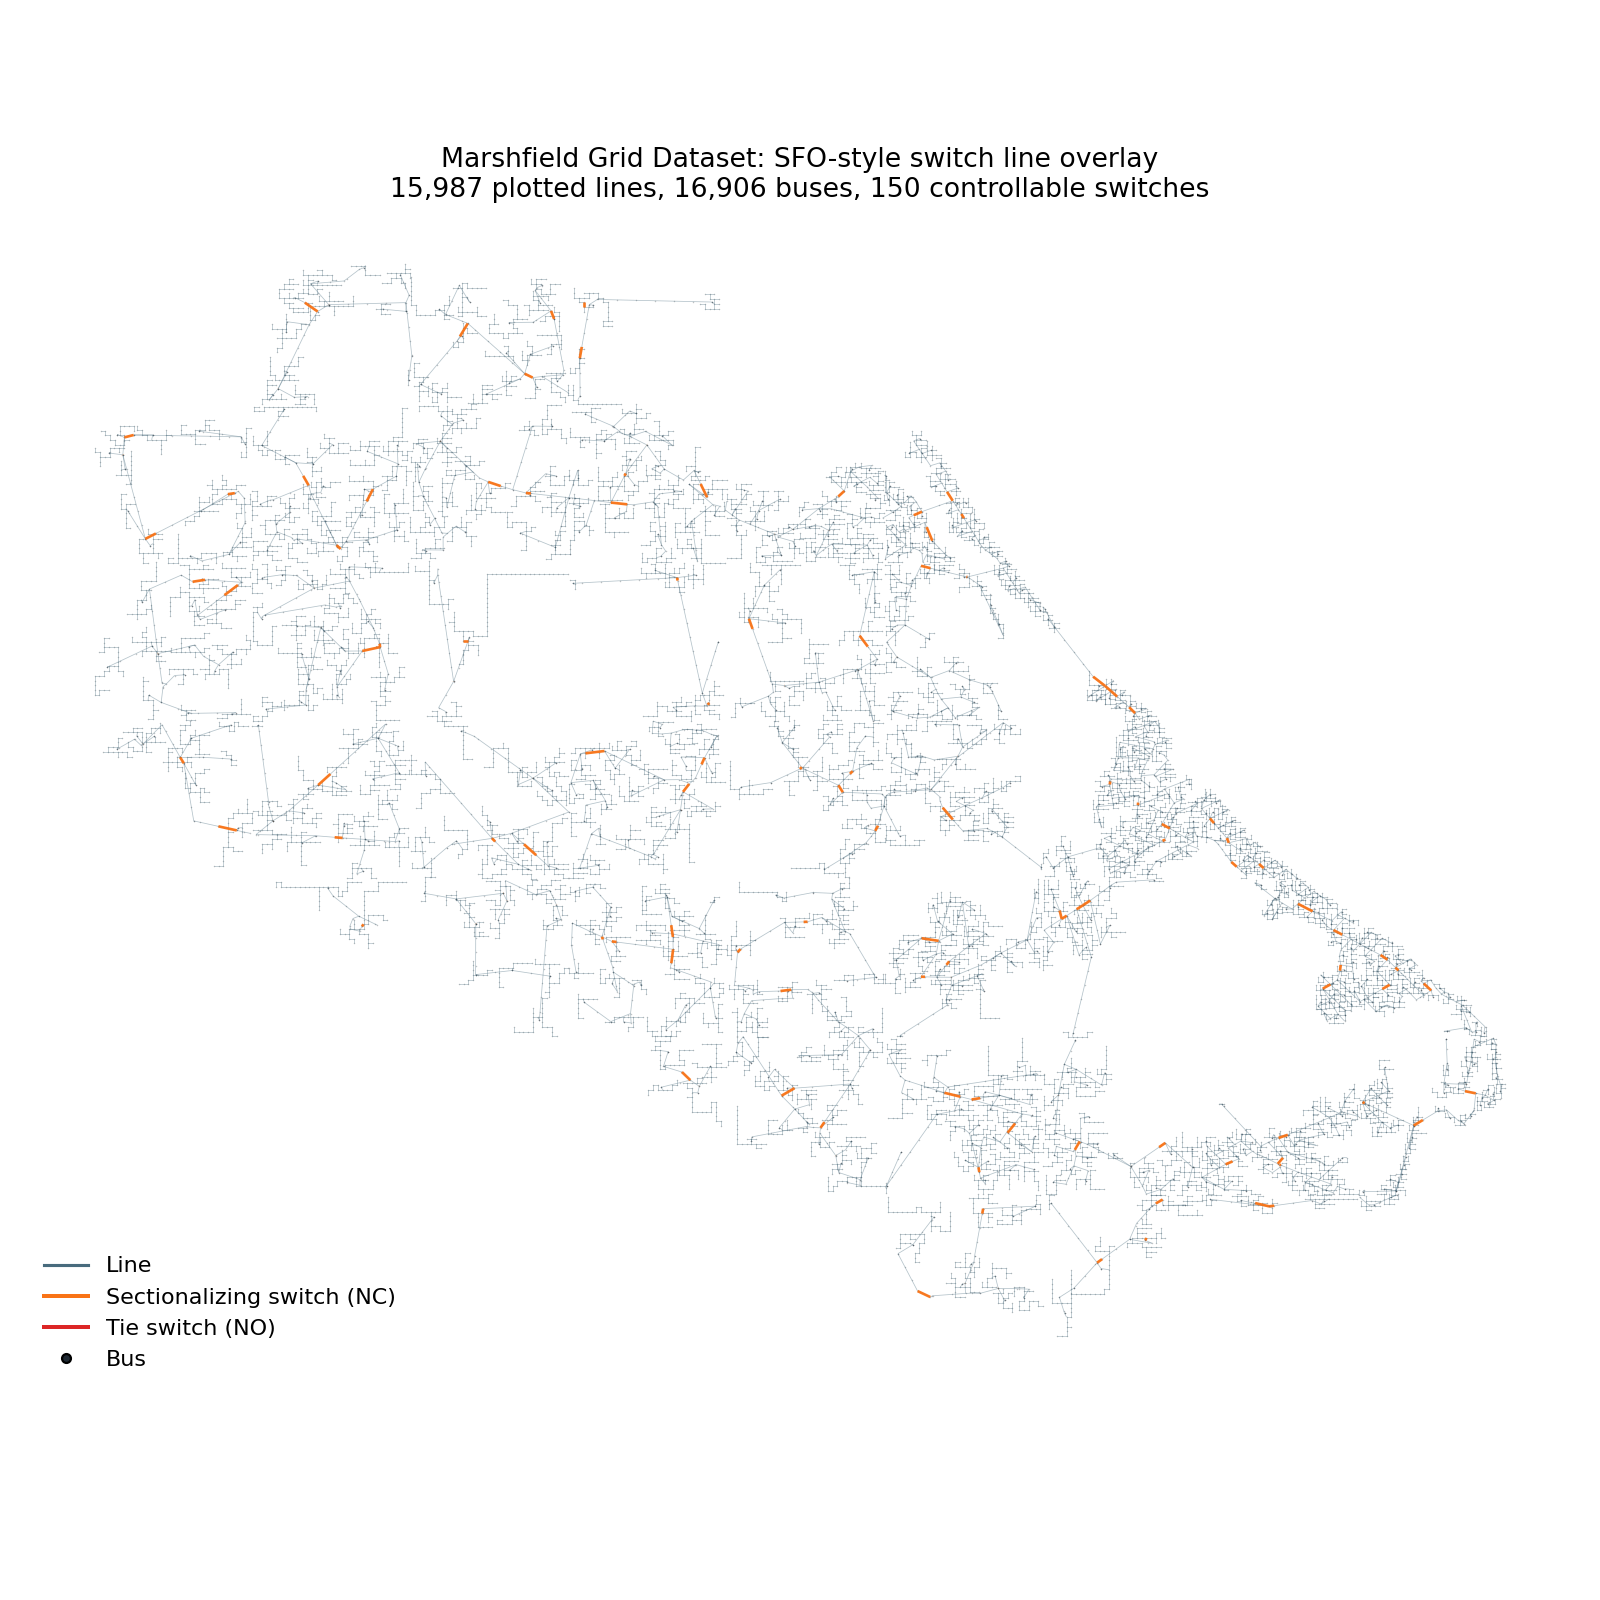

output_path /home/grahamhults/projects/Flood-RM/locations/...
line_count 15987
bus_count 16906
switch_count 150
sectionalizing_switch_count 150
tie_switch_count 0
sectionalizing_switch_segments_plotted 150
tie_switch_segments_plotted 0
zero_length_tie_ticks 0
Name: augmented_network_switch_overlay, dtype: object

In [5]:
from IPython.display import Image, display

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
from shapely.geometry import LineString

sectionalizing_switch_color = "#f97316"
tie_switch_color = "#dc2626"


def _point_gdf(df, x="lon", y="lat"):
    if df.empty or x not in df or y not in df:
        return gpd.GeoDataFrame(df.copy(), geometry=[], crs=4326)
    rows = df.dropna(subset=[x, y]).copy()
    return gpd.GeoDataFrame(rows, geometry=gpd.points_from_xy(rows[x], rows[y]), crs=4326)


def _line_gdf(df):
    required = ["from_lon", "from_lat", "to_lon", "to_lat"]
    if df.empty or any(column not in df for column in required):
        return gpd.GeoDataFrame(df.copy(), geometry=[], crs=4326)
    rows = df.dropna(subset=required).copy()
    if "has_buscoords" in rows:
        rows = rows[rows["has_buscoords"].astype(str).str.lower().eq("true")]
    rows["geometry"] = [
        LineString([(row.from_lon, row.from_lat), (row.to_lon, row.to_lat)])
        for row in rows.itertuples()
    ]
    return gpd.GeoDataFrame(rows, geometry="geometry", crs=4326)


def _switch_segments(switches, buses, lines):
    if switches.empty:
        return gpd.GeoDataFrame(geometry=[], crs=3857), 0
    bus_geom = buses.dropna(subset=["bus"]).set_index("bus").geometry
    line_key = "line_name" if "line_name" in lines else "line"
    line_geom = lines.dropna(subset=[line_key]).set_index(line_key).geometry if line_key in lines else {}
    records = []
    zero_length = 0
    for row in switches.itertuples():
        role = str(getattr(row, "switch_role", ""))
        geom = None
        if role == "sectionalizing" and bool(getattr(row, "opens_existing_line", False)):
            geom = line_geom.get(str(getattr(row, "associated_line_name", "")))
        elif role == "tie":
            left = bus_geom.get(str(getattr(row, "from_bus", "")))
            right = bus_geom.get(str(getattr(row, "to_bus", "")))
            if left is not None and right is not None:
                if left.equals(right):
                    zero_length += 1
                    geom = LineString([(left.x - 20, left.y - 20), (left.x + 20, left.y + 20)])
                else:
                    geom = LineString([left, right])
        if geom is not None and not geom.is_empty:
            records.append({**row._asdict(), "geometry": geom})
    return gpd.GeoDataFrame(records, geometry="geometry", crs=3857), zero_length


registry_dir = grid["asset_registry"]
smart_ds_compat_dir = grid["augmented_artifacts"]
output_path = grid["figures"] / "augmented_network_switch_overlay.png"
output_path.parent.mkdir(parents=True, exist_ok=True)

buses = _point_gdf(pd.read_csv(registry_dir / "buses.csv")).to_crs(3857)
lines = _line_gdf(pd.read_csv(registry_dir / "lines.csv")).to_crs(3857)
switches = _point_gdf(pd.read_parquet(smart_ds_compat_dir / "controllable_switches.parquet")).to_crs(3857)
switch_lines, zero_length = _switch_segments(switches, buses, lines)
role_counts = switches["switch_role"].value_counts() if "switch_role" in switches else pd.Series(dtype=int)

fig, ax = plt.subplots(figsize=(10, 10))
if not lines.empty:
    lines.plot(ax=ax, color="#486b7d", linewidth=0.35, alpha=0.40)
if not switch_lines.empty:
    switch_lines.plot(
        ax=ax,
        color=switch_lines["switch_role"].map({"sectionalizing": sectionalizing_switch_color, "tie": tie_switch_color}),
        linewidth=switch_lines["switch_role"].map({"sectionalizing": 1.2, "tie": 1.6}).fillna(1.2),
        alpha=0.95,
    )
if not buses.empty:
    buses.plot(ax=ax, color="#1f2933", markersize=0.45, alpha=0.28)
ax.set_title(
    "Grid Dataset: SFO-style switch line overlay
"
    f"{len(lines):,} plotted lines, {len(buses):,} buses, {len(switches):,} controllable switches"
)
ax.axis("off")
ax.legend(
    handles=[
        Line2D([0], [0], color="#486b7d", lw=1.4, label="Line"),
        Line2D([0], [0], color=sectionalizing_switch_color, lw=1.8, label="Sectionalizing switch (NC)"),
        Line2D([0], [0], color=tie_switch_color, lw=1.8, label="Tie switch (NO)"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#1f2933", markersize=4, label="Bus"),
    ],
    loc="lower left",
    frameon=False,
)
fig.tight_layout()
fig.savefig(output_path, dpi=160)
plt.close(fig)

result = {
    "output_path": str(output_path),
    "line_count": len(lines),
    "bus_count": len(buses),
    "switch_count": len(switches),
    "sectionalizing_switch_count": int(role_counts.get("sectionalizing", 0)),
    "tie_switch_count": int(role_counts.get("tie", 0)),
    "sectionalizing_switch_segments_plotted": int((switch_lines["switch_role"] == "sectionalizing").sum()) if not switch_lines.empty else 0,
    "tie_switch_segments_plotted": int((switch_lines["switch_role"] == "tie").sum()) if not switch_lines.empty else 0,
    "zero_length_tie_ticks": zero_length,
}
display(Image(filename=result["output_path"]))
display(pd.Series(result, name="augmented_network_switch_overlay"))